# Random Forest Crime Prediction Assignment

## Overview
In this assignment, you will use a **recent real-world crime dataset** to build a **Random Forest classification model**. You will explore the data, prepare it for modeling, train a classifier, evaluate the results, and interpret feature importance.

## Learning Goals
By the end of this assignment, you should be able to:

- explain the difference between **features** and a **target variable**
- prepare data for machine learning
- build a **Random Forest** classifier in Python
- evaluate a classification model using accuracy, a confusion matrix, and a classification report
- interpret **feature importance**
- connect model results to real-world patterns and possible limitations

## Important Note
In this notebook, you are **not predicting whether a crime will happen**.  
You are predicting:

> **Was an arrest made?** (`True` or `False`)

That means your model is learning patterns related to **arrest outcomes**, not crime occurrence itself.


## Step 1: Load the Data

We will use a recent subset of the Chicago crime dataset. The dataset is large, so we will pull a manageable sample for class use.


In [15]:
import pandas as pd
import matplotlib.pyplot as plt

url = "https://data.cityofchicago.org/resource/ijzp-q8t2.csv?$limit=50000"
df = pd.read_csv(url)

df.head()

,id,case_number,date,block,iucr,primary_type,description,location_description,arrest,domestic,...,ward,community_area,fbi_code,x_coordinate,y_coordinate,year,updated_on,latitude,longitude,location
0,14137084,JK181553,2026-03-15T00:00:00.000,007XX W 123RD ST,1477,WEAPONS VIOLATION,RECKLESS FIREARM DISCHARGE,STREET,False,False,...,9,53.0,15,1173402.0,1823299.0,2026,2026-03-22T15:41:33.000,41.670546,-87.641004,"\n, \n(41.670546154, -87.641004119)"
1,14140361,JK185544,2026-03-15T00:00:00.000,068XX S STEWART AVE,1582,OFFENSE INVOLVING CHILDREN,CHILD PORNOGRAPHY,SCHOOL - PUBLIC BUILDING,False,False,...,6,68.0,17,1174651.0,1859743.0,2026,2026-03-22T15:41:33.000,41.770526,-87.635351,"\n, \n(41.770525914, -87.635351487)"
2,14138902,JK183837,2026-03-15T00:00:00.000,044XX N MONITOR AVE,0760,BURGLARY,BURGLARY FROM MOTOR VEHICLE,STREET,False,False,...,38,15.0,06,1136544.0,1928981.0,2026,2026-03-22T15:41:33.000,41.961289,-87.773383,"\n, \n(41.961288511, -87.773383414)"
3,14140243,JK185630,2026-03-15T00:00:00.000,011XX W CARROLL AVE,1320,CRIMINAL DAMAGE,TO VEHICLE,STREET,False,False,...,27,28.0,14,1168916.0,1902406.0,2026,2026-03-22T15:41:33.000,41.887723,-87.655139,"\n, \n(41.887723159, -87.655139133)"
4,14137377,JK181905,2026-03-15T00:00:00.000,062XX S MOZART ST,051A,ASSAULT,AGGRAVATED - HANDGUN,APARTMENT,False,False,...,15,66.0,04A,1158453.0,1863070.0,2026,2026-03-22T15:41:33.000,41.780001,-87.694637,"\n, \n(41.78000107, -87.694636659)"


## Step 2: Explore the Data

Look at the structure of the dataset.

### Questions
1. What does each row represent? An individual crime case.
2. Which variables look potentially useful for prediction? Checking for an arrest seems useful, as well as crimes and crime descriptions.
3. Which variable appears to be the target for this assignment?
If an arrest was made true/false.

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    50000 non-null  int64  
 1   case_number           50000 non-null  object 
 2   date                  50000 non-null  object 
 3   block                 50000 non-null  object 
 4   iucr                  50000 non-null  object 
 5   primary_type          50000 non-null  object 
 6   description           50000 non-null  object 
 7   location_description  49756 non-null  object 
 8   arrest                50000 non-null  bool   
 9   domestic              50000 non-null  bool   
 10  beat                  50000 non-null  int64  
 11  district              50000 non-null  int64  
 12  ward                  50000 non-null  int64  
 13  community_area        49998 non-null  float64
 14  fbi_code              50000 non-null  object 
 15  x_coordinate       

In [17]:
df.describe(include='all')

,id,case_number,date,block,iucr,primary_type,description,location_description,arrest,domestic,...,ward,community_area,fbi_code,x_coordinate,y_coordinate,year,updated_on,latitude,longitude,location
count,5.000000e+04,50000,50000,50000,50000,50000,50000,49756,50000,50000,...,50000.000000,49998.000000,50000,4.994200e+04,4.994200e+04,50000.000000,50000,49942.000000,49942.000000,49942
unique,NaN,49997,27339,16919,285,28,267,107,2,2,...,NaN,NaN,24,NaN,NaN,NaN,70,NaN,NaN,33587
top,NaN,JK173315,2026-01-01T00:00:00.000,0000X N STATE ST,0486,THEFT,SIMPLE,STREET,False,False,...,NaN,NaN,06,NaN,NaN,NaN,2026-03-14T15:41:39.000,NaN,NaN,"\n, \n(41.754592961, -87.741528537)"
freq,NaN,2,48,135,4160,11050,6155,13256,42189,40245,...,NaN,NaN,12263,NaN,NaN,NaN,44201,NaN,NaN,76
mean,1.407270e+07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,22.818360,36.374235,NaN,1.165753e+06,1.887011e+06,2025.816200,NaN,41.845531,-87.667234,NaN
std,6.001344e+05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,13.930557,21.393260,NaN,1.620603e+04,3.124905e+04,0.387325,NaN,0.085934,0.059008,NaN
min,2.898000e+04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.000000,1.000000,NaN,1.094587e+06,1.814333e+06,2025.000000,NaN,41.645288,-87.927365,NaN
25%,1.407773e+07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,9.000000,22.000000,NaN,1.154556e+06,1.860226e+06,2026.000000,NaN,41.771996,-87.707972,NaN
50%,1.409856e+07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,22.000000,32.000000,NaN,1.167584e+06,1.892872e+06,2026.000000,NaN,41.861843,-87.660306,NaN
75%,1.411847e+07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,34.000000,53.000000,NaN,1.176957e+06,1.909938e+06,2026.000000,NaN,41.908436,-87.626156,NaN


## Step 3: Data Cleaning

We will keep a smaller set of variables for this assignment.

- `primary_type`: type of crime
- `arrest`: whether an arrest was made
- `domestic`: whether the incident was domestic-related
- `district`: police district
- `latitude`, `longitude`: location

Then we will remove rows with missing values.


In [18]:
df = df[['primary_type', 'arrest', 'domestic', 'district', 'latitude', 'longitude']]
df = df.dropna()

df.head()

,primary_type,arrest,domestic,district,latitude,longitude
0,WEAPONS VIOLATION,False,False,5,41.670546,-87.641004
1,OFFENSE INVOLVING CHILDREN,False,False,7,41.770526,-87.635351
2,BURGLARY,False,False,16,41.961289,-87.773383
3,CRIMINAL DAMAGE,False,False,12,41.887723,-87.655139
4,ASSAULT,False,False,8,41.780001,-87.694637


### Short Response
Why might missing values cause problems in machine learning and mapping?
Machines do not handle unexpected data well. It must be pruned to produce workable results.

## Step 4: Interactive Crime Map

Now that the data has been cleaned, we can build a map using latitude and longitude.

We are placing this **after data cleaning** because missing values in location fields can cause mapping tools to fail.

### Note
We will use `CartoDB positron` for the base map. This tile option often works better in notebook environments than the default map tiles.


In [19]:
import folium

m = folium.Map(
    location=[df['latitude'].mean(), df['longitude'].mean()],
    zoom_start=11,
    tiles="CartoDB positron"
)

sample_df = df.sample(1000, random_state=42)

for _, row in sample_df.iterrows():
    color = "red" if row['arrest'] else "blue"
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=2,
        color=color,
        fill=True,
        fill_opacity=0.6
    ).add_to(m)

m

### Interpretation Questions
1. Do crime points appear evenly spread out, or do they cluster in certain areas? The crime points tend to cluster in dense, urban areas.
2. Do you see any visible differences between arrest and non-arrest locations? Not particularly, aside from arrests not overlapping often.
3. If location turns out to be important later, does this map help explain why? Yes, it would be able to determine criminal clustering. It may prove useful for future deterrence.


## Step 5: Arrest Rate by Crime Type

This chart helps you see which crime categories are more likely to lead to an arrest.


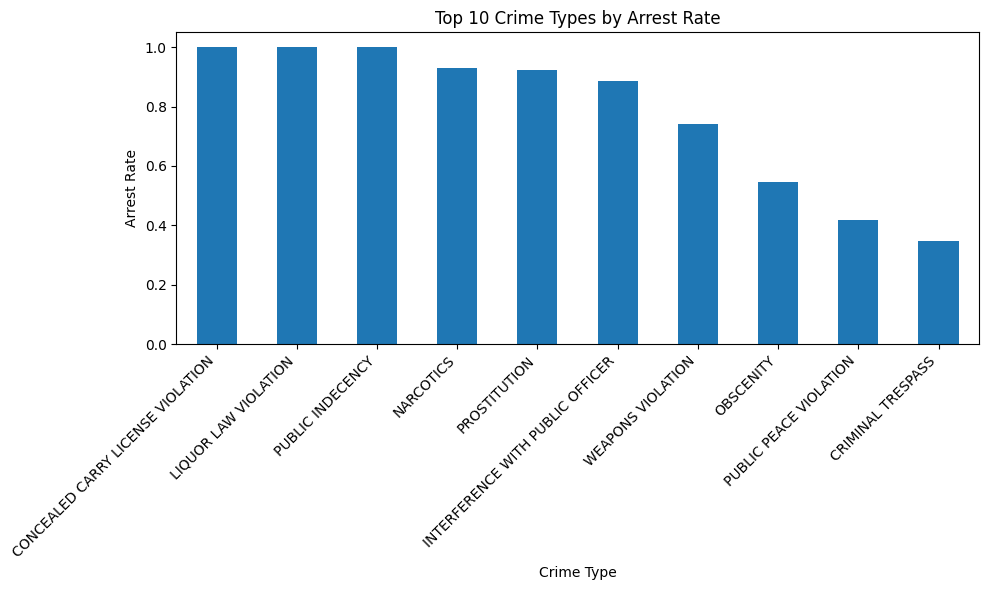

In [20]:
arrest_rates = df.groupby('primary_type')['arrest'].mean().sort_values(ascending=False)

plt.figure(figsize=(10,6))
arrest_rates.head(10).plot(kind='bar')
plt.title("Top 10 Crime Types by Arrest Rate")
plt.ylabel("Arrest Rate")
plt.xlabel("Crime Type")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Interpretation Question
Which crime types seem most likely to lead to arrest? Does this surprise you?
Not really, the oft arrests are common, easily provable crimes. The rest are either less common, or more petty affairs.

## Step 6: Feature Engineering

Machine learning models need numeric input. Since `primary_type` and `district` are categorical, we will convert them into dummy variables.


In [21]:
df = pd.get_dummies(df, columns=['primary_type', 'district'], drop_first=True)
df.head()

,arrest,domestic,latitude,longitude,primary_type_ASSAULT,primary_type_BATTERY,primary_type_BURGLARY,primary_type_CONCEALED CARRY LICENSE VIOLATION,primary_type_CRIMINAL DAMAGE,primary_type_CRIMINAL SEXUAL ASSAULT,...,district_14,district_15,district_16,district_17,district_18,district_19,district_20,district_22,district_24,district_25
0,False,False,41.670546,-87.641004,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,41.770526,-87.635351,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,41.961289,-87.773383,False,False,True,False,False,False,...,False,False,True,False,False,False,False,False,False,False
3,False,False,41.887723,-87.655139,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,41.780001,-87.694637,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


## Step 7: Define Features and Target

Here is the key setup:

- `X` = the input features used to make predictions
- `y` = the target variable we want to predict

In this assignment:

> `y = arrest`

So the model predicts whether an arrest was made.


In [22]:
X = df.drop('arrest', axis=1)
y = df['arrest']

## Step 8: Train/Test Split

We split the data so the model trains on one portion and is evaluated on unseen data.


In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Step 9: Train the Random Forest Model


In [24]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

## Step 10: Evaluate the Model

We will use:
- **Accuracy**
- **Confusion Matrix**
- **Classification Report**


In [25]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

y_pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.8728601461607769

Confusion Matrix:
[[7964  478]
 [ 792  755]]

Classification Report:
              precision    recall  f1-score   support

       False       0.91      0.94      0.93      8442
        True       0.61      0.49      0.54      1547

    accuracy                           0.87      9989
   macro avg       0.76      0.72      0.73      9989
weighted avg       0.86      0.87      0.87      9989



## Step 11: Feature Importance

Feature importance tells us which variables had the biggest influence on the model’s predictions.

A larger value means the model used that variable more heavily when making decisions.


In [26]:
importances = pd.Series(rf.feature_importances_, index=X.columns)
top_features = importances.sort_values(ascending=False).head(10)
top_features

,0
latitude,0.327588
longitude,0.321992
primary_type_NARCOTICS,0.145152
primary_type_WEAPONS VIOLATION,0.058471
primary_type_INTERFERENCE WITH PUBLIC OFFICER,0.019821
domestic,0.011136
primary_type_CRIMINAL DAMAGE,0.010045
primary_type_CRIMINAL TRESPASS,0.009382
primary_type_MOTOR VEHICLE THEFT,0.008335
primary_type_BATTERY,0.007937


## Step 12: Visualize Feature Importance

This plot gives a clearer picture of what the model relied on most.


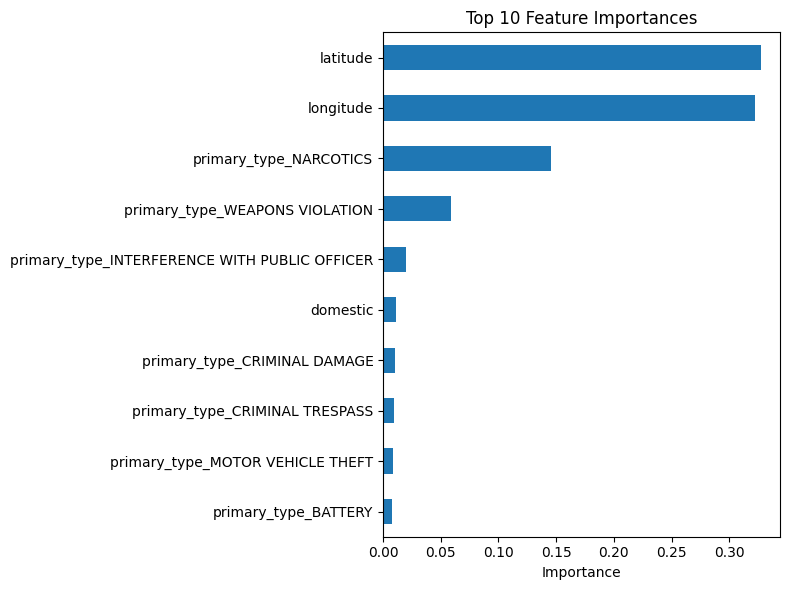

In [27]:
plt.figure(figsize=(8,6))
top_features.sort_values().plot(kind='barh')
plt.title("Top 10 Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

### Interpretation Questions
1. Which features matter the most? Lattitude or logitude, mostly.
2. Does the model seem to rely more on **location** or **crime type**? Given the top features are for coordinates, the former it seems.
3. What does that suggest about arrest outcomes in the dataset? They occur often in specific areas.


## Step 13: Cross Validation

Cross validation helps us check whether the model performs consistently across different subsets of the data.


In [28]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(rf, X, y, cv=5)
print("Cross-validation scores:", scores)
print("Average cross-validation score:", scores.mean())

Cross-validation scores: [0.86935629 0.86895585 0.87044453 0.87484982 0.8628354 ]
Average cross-validation score: 0.8692883798129083


## Step 14: Reflection

Write a short reflection that answers the following:

1. What does the model do well? It demonstrates recorded criminal activity in a area, and shows their locations.
2. What are its limitations? These are arrests, not all incidents of crime it appears.
3. What does feature importance suggest about the strongest predictors of arrest? Certain areas and possession of drugs or firearm violations.
4. Why is it important to remember that this model predicts **arrest outcomes** rather than crime itself? It only is a slice of the data, and some events may be overrepresented in this dataset.
5. Should a model like this be used in real-world policing decisions? Why or why not? Alongside others, I think so. It can serve a use.
